# 5-Fold Ensemble Inference 

**Pipeline Logic:**
1. **Segmentation (Model 2a):** Predict lesion mask on normalized image
2. **Binarize & Count:** Binarize mask and count white pixels
3. **Normal Filter:** If mask is mostly empty → P(Normal) = 1.0
4. **Mask RAW Image:** Apply binary mask to raw (unnormalized) image
5. **Normalize Masked Image:** Normalize the masked image for classifier
6. **Classification with TTA:** Classify using both original and horizontally flipped images
7. **Confidence-Weighted Ensemble:** Average probabilities across 5 folds (Soft Voting)

**Key Features:**
- Memory-safe: Only one fold's models loaded at a time
- Test-Time Augmentation (TTA) for classification
- Soft Voting ensemble across 5 folds

# 0. Download

In [1]:
# ═══════════════════════════════════════════════════════════════════════════
# DOWNLOAD AND EXTRACT DATA
# ═══════════════════════════════════════════════════════════════════════════
import gdown
import zipfile
import os

# Download data
url = "https://drive.google.com/drive/folders/1uTP8xcNqwi2MYUptg3BZwGjjDOMFhNBC?usp=sharing"
gdown.download_folder(url, output="breast_ultrasound_data", quiet=False)

url = "https://drive.google.com/drive/folders/14EVbUV2WT38i96UAmKF7pd13GyWqu-qR?usp=sharing"
gdown.download_folder(url, output="splits", quiet=False)

# Unzip images
zip_path = "breast_ultrasound_data/Training_Images.zip"
extract_to = "breast_ultrasound_data/training_images"

os.makedirs(extract_to, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_to)

print(f"✓ Unzipped files: {len(os.listdir(extract_to))}")

Retrieving folder contents


Processing file 1VGohBSMxPSyxJm912O9O-x6fmA-buoSE Training_Images.zip
Processing file 1Oxbq4hGIyU6No9BCiQSsyXL1Dz41R-NU training_metadata.xlsx


Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From (original): https://drive.google.com/uc?id=1VGohBSMxPSyxJm912O9O-x6fmA-buoSE
From (redirected): https://drive.google.com/uc?id=1VGohBSMxPSyxJm912O9O-x6fmA-buoSE&confirm=t&uuid=c6f70ef2-33f4-42b7-bb7f-5a800b657da9
To: /kaggle/working/breast_ultrasound_data/Training_Images.zip
100%|██████████| 582M/582M [00:02<00:00, 216MB/s] 
Downloading...
From: https://drive.google.com/uc?id=1Oxbq4hGIyU6No9BCiQSsyXL1Dz41R-NU
To: /kaggle/working/breast_ultrasound_data/training_metadata.xlsx
100%|██████████| 43.9k/43.9k [00:00<00:00, 40.5MB/s]
Download completed
Retrieving folder contents


Processing file 1eHpZZliVD3id0_882NA4mQ4bC-0IR5Uw fold_0_train.csv
Processing file 1xJx7b1XnSOVwoi5CLmhWWegRjd9d987x fold_0_val.csv
Processing file 104L5nzPP5OsFUB_k80UwQhfQSdieFa81 fold_1_train.csv
Processing file 1EsHJUU14Hy4YLNFPwPrMxPdH1CANyZ4K fold_1_val.csv
Processing file 1-nw-dwBodjx_WElic_7fYGUpAYE_o1ew fold_2_train.csv
Processing file 18UuKP8iotw-zQhgsD2XcckYenIgmq3QL fold_2_val.csv
Processing file 1mhNj2iPZsSAuj7yC4ijgLiolbObPeWbr fold_3_train.csv
Processing file 1BMs5bEqgL3C4CqXj8_qh24TsIRK0dfYW fold_3_val.csv
Processing file 1gmQ6DKFtZhTFcGdfnZmC3n9bUX70_d-0 fold_4_train.csv
Processing file 1FYlevjQ_84GZyHYyeSWcLt0cbVU3DXyW fold_4_val.csv


Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From: https://drive.google.com/uc?id=1eHpZZliVD3id0_882NA4mQ4bC-0IR5Uw
To: /kaggle/working/splits/fold_0_train.csv
100%|██████████| 35.9k/35.9k [00:00<00:00, 39.7MB/s]
Downloading...
From: https://drive.google.com/uc?id=1xJx7b1XnSOVwoi5CLmhWWegRjd9d987x
To: /kaggle/working/splits/fold_0_val.csv
100%|██████████| 9.03k/9.03k [00:00<00:00, 14.4MB/s]
Downloading...
From: https://drive.google.com/uc?id=104L5nzPP5OsFUB_k80UwQhfQSdieFa81
To: /kaggle/working/splits/fold_1_train.csv
100%|██████████| 35.9k/35.9k [00:00<00:00, 35.9MB/s]
Downloading...
From: https://drive.google.com/uc?id=1EsHJUU14Hy4YLNFPwPrMxPdH1CANyZ4K
To: /kaggle/working/splits/fold_1_val.csv
100%|██████████| 9.04k/9.04k [00:00<00:00, 15.8MB/s]
Downloading...
From: https://drive.google.com/uc?id=1-nw-dwBodjx_WElic_7fYGUpAYE_o1ew
To: /kaggle/working/splits/fold_2_train.csv
100%|██████████| 35.9k/35.9k [00:00<0

✓ Unzipped files: 1


## 1. Configuration

In [2]:
# ═══════════════════════════════════════════════════════════════════════════
# 🎯 ENSEMBLE CONFIGURATION
# ═══════════════════════════════════════════════════════════════════════════

# Model Architecture (must match the trained models)
MODEL_2A_ARCH = 'EfficientUNet'  # Segmentation model architecture
MODEL_2B_ARCH = 'ResNet18'       # Classification model architecture

# Path to K-Fold Models
MODELS_BASE_PATH = '/kaggle/input/models/samansimpich/aaib-k-fold-models/tensorflow1/default/1/'

# Validation Fold to Evaluate (0-4)
EVAL_FOLD = 0

# Pipeline Parameters
MASK_THRESHOLD = 50              # Minimum white pixels to consider as "lesion present"
MASK_BINARIZE_THRESHOLD = 0.4    # Probability threshold for binarizing segmentation output

# Data Configuration
IMG_SIZE = 224
BATCH_SIZE = 1  # MUST be 1 for per-sample probability tracking

# Number of Folds
NUM_FOLDS = 5

# Data Paths
SPLITS_DIR = 'splits'
IMAGE_FOLDER = 'breast_ultrasound_data/training_images/training_images'

# Classification dropout rate (must match training)
DROPOUT_RATE = 0.3

print("="*70)
print("🔬 5-FOLD ENSEMBLE INFERENCE CONFIGURATION")
print("="*70)
print(f"Segmentation Model (2a): {MODEL_2A_ARCH}")
print(f"Classification Model (2b): {MODEL_2B_ARCH}")
print(f"Evaluation Fold: fold_{EVAL_FOLD}_val.csv")
print(f"Mask Threshold: {MASK_THRESHOLD} pixels")
print(f"Mask Binarize Threshold: {MASK_BINARIZE_THRESHOLD}")
print(f"TTA: Enabled (Horizontal Flip)")
print(f"Ensemble Method: Soft Voting (Probability Averaging)")
print("="*70)

🔬 5-FOLD ENSEMBLE INFERENCE CONFIGURATION
Segmentation Model (2a): EfficientUNet
Classification Model (2b): ResNet18
Evaluation Fold: fold_0_val.csv
Mask Threshold: 50 pixels
Mask Binarize Threshold: 0.4
TTA: Enabled (Horizontal Flip)
Ensemble Method: Soft Voting (Probability Averaging)


## 2. Imports & Setup

In [3]:
# Install dependencies if needed
!pip install segmentation-models-pytorch albumentations -q

import os
import glob
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as models
import segmentation_models_pytorch as smp
from torch.utils.data import Dataset, DataLoader

import albumentations as A
from albumentations.pytorch import ToTensorV2

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    balanced_accuracy_score,
    accuracy_score
)

# Device Configuration
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✓ Using device: {DEVICE}")
if torch.cuda.is_available():
    print(f"  GPU: {torch.cuda.get_device_name(0)}")
    print(f"  Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")

print("✓ All imports loaded successfully!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 6.5 MB/s eta 0:00:00


/usr/local/lib/python3.12/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` 

✓ Using device: cuda
  GPU: Tesla P100-PCIE-16GB
  Memory: 17.06 GB
✓ All imports loaded successfully!


## 3. Model Factory Functions

In [4]:
# ═══════════════════════════════════════════════════════════════════════════
# MODEL 2A: SEGMENTATION (using segmentation_models_pytorch)
# ═══════════════════════════════════════════════════════════════════════════

def get_model_2a(arch_name):
    """
    Create a segmentation model for Task 2a.
    
    Args:
        arch_name: 'ResNetUNet', 'EfficientUNet', or 'AttentionUNet'
    
    Returns:
        torch.nn.Module with sigmoid output
    """
    if arch_name == 'ResNetUNet':
        base_model = smp.Unet(
            encoder_name='resnet34',
            encoder_weights=None,
            in_channels=1,
            classes=1,
            activation=None
        )
    elif arch_name == 'EfficientUNet':
        base_model = smp.Unet(
            encoder_name='efficientnet-b0',
            encoder_weights=None,
            in_channels=1,
            classes=1,
            activation=None
        )
    elif arch_name == 'AttentionUNet':
        base_model = smp.UnetPlusPlus(
            encoder_name='resnet34',
            encoder_weights=None,
            in_channels=1,
            classes=1,
            activation=None
        )
    else:
        raise ValueError(f"Unknown segmentation architecture: {arch_name}")
    
    # Wrapper to apply sigmoid
    class SegmentationModelWrapper(nn.Module):
        def __init__(self, model):
            super().__init__()
            self.model = model
        
        def forward(self, x):
            return torch.sigmoid(self.model(x))
    
    return SegmentationModelWrapper(base_model)


# ═══════════════════════════════════════════════════════════════════════════
# MODEL 2B: CLASSIFICATION (using torchvision)
# ═══════════════════════════════════════════════════════════════════════════

def get_model_2b(arch_name, dropout_rate=0.3):
    """
    Create a binary classification model for Task 2b.
    
    Args:
        arch_name: 'EfficientNetB0', 'ResNet18', or 'MobileNetV3'
        dropout_rate: Dropout rate (must match training)
    
    Returns:
        torch.nn.Module with 2-class output
    """
    if arch_name == 'EfficientNetB0':
        model = models.efficientnet_b0(weights=None)
        model.features[0][0] = nn.Conv2d(
            1, 32, kernel_size=3, stride=2, padding=1, bias=False
        )
        in_features = model.classifier[1].in_features
        model.classifier = nn.Sequential(
            nn.Dropout(p=dropout_rate),
            nn.Linear(in_features, 2)
        )
    
    elif arch_name == 'ResNet18':
        model = models.resnet18(weights=None)
        model.conv1 = nn.Conv2d(
            1, 64, kernel_size=7, stride=2, padding=3, bias=False
        )
        in_features = model.fc.in_features
        model.fc = nn.Sequential(
            nn.Dropout(p=dropout_rate),
            nn.Linear(in_features, 2)
        )
    
    elif arch_name == 'MobileNetV3':
        model = models.mobilenet_v3_small(weights=None)
        model.features[0][0] = nn.Conv2d(
            1, 16, kernel_size=3, stride=2, padding=1, bias=False
        )
        in_features = model.classifier[3].in_features
        model.classifier[3] = nn.Sequential(
            nn.Dropout(p=dropout_rate),
            nn.Linear(in_features, 2)
        )
    
    else:
        raise ValueError(f"Unknown classification architecture: {arch_name}")
    
    return model


print("✓ Model factory functions defined")

✓ Model factory functions defined


## 4. Dataset & DataLoader

In [5]:
# ═══════════════════════════════════════════════════════════════════════════
# PIPELINE EVALUATION DATASET
# Returns both normalized (for Model 2a) and raw (for masking) images
# ═══════════════════════════════════════════════════════════════════════════

class PipelineEvaluationDataset(Dataset):
    def __init__(self, dataframe, image_dir, img_size=224):
        self.image_dir = image_dir
        self.img_size = img_size
        
        # Group by image_filename to avoid duplicates
        grouped = dataframe.groupby('image_filename').agg({
            'label': 'max',
            'patient_id': 'first'
        }).reset_index()
        
        self.data = grouped.dropna(subset=['label']).reset_index(drop=True)
        self.data['label'] = self.data['label'].astype(int)
        
        # Transforms
        self.transform_normalized = A.Compose([
            A.Resize(img_size, img_size),
            A.Normalize(mean=(0.5,), std=(0.5,)),
            ToTensorV2()
        ])
        
        self.transform_raw = A.Compose([
            A.Resize(img_size, img_size),
            ToTensorV2()
        ])
        
        print(f"Dataset: {len(self.data)} unique images")
    
    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, idx):
        row = self.data.iloc[idx]
        img_name = row['image_filename']
        label = int(row['label'])
        
        # Load image
        img_path = os.path.join(self.image_dir, img_name)
        image = np.array(Image.open(img_path).convert("L"))
        
        # Normalized image (for Model 2a - Segmentation)
        aug_normalized = self.transform_normalized(image=image)
        image_normalized = aug_normalized['image']
        
        # Raw image (for masking, [0,1] range)
        aug_raw = self.transform_raw(image=image)
        image_raw = aug_raw['image'].float() / 255.0
        
        # Add channel dimension if needed
        if image_normalized.ndim == 2:
            image_normalized = image_normalized.unsqueeze(0)
        if image_raw.ndim == 2:
            image_raw = image_raw.unsqueeze(0)
        
        return image_normalized, image_raw, label, img_name


# ═══════════════════════════════════════════════════════════════════════════
# LOAD VALIDATION DATA
# ═══════════════════════════════════════════════════════════════════════════

print(f"{'='*60}")
print(f"LOADING VALIDATION DATA (Fold {EVAL_FOLD})")
print(f"{'='*60}")

val_csv_path = f'{SPLITS_DIR}/fold_{EVAL_FOLD}_val.csv'
val_df = pd.read_csv(val_csv_path)

# Handle column naming
if 'filename' in val_df.columns and 'image_filename' not in val_df.columns:
    val_df = val_df.rename(columns={'filename': 'image_filename'})

print(f"✓ Validation Set: {len(val_df)} rows")
print(f"  Labels: {dict(val_df['label'].value_counts().sort_index())}")

# Create dataset and loader
eval_dataset = PipelineEvaluationDataset(val_df, IMAGE_FOLDER, img_size=IMG_SIZE)
eval_loader = DataLoader(eval_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f"✓ DataLoader created with {len(eval_loader)} batches")

LOADING VALIDATION DATA (Fold 0)
✓ Validation Set: 301 rows
  Labels: {0: np.int64(139), 1: np.int64(85), 2: np.int64(77)}
Dataset: 301 unique images
✓ DataLoader created with 301 batches


## 5. Find Model Paths for All Folds

In [7]:
# ═══════════════════════════════════════════════════════════════════════════
# FIND MODEL PATHS FOR ALL 5 FOLDS
# Model naming convention: best_model_{TASK}_{ARCH}_f{FOLD}-{score}.pth
# ═══════════════════════════════════════════════════════════════════════════

import os
import glob

def find_model_path(models_dir, task, arch, fold):
    """
    Find the model path matching the pattern using recursive search.
    Handles varying score formats and unknown sub-directory structures.
    """
    # The file pattern itself
    pattern = f"best_model_{task}_{arch}_f{fold}-*.pth"
    
    # Add "**" to allow glob to search through any intermediate folders (or no folders)
    search_path = os.path.join(models_dir, "**", pattern)
    
    # Enable recursive=True so '**' works correctly
    matches = glob.glob(search_path, recursive=True)
    
    if not matches:
        raise FileNotFoundError(f"No model found matching: {search_path}")
    
    # Return the first match 
    return matches[0]

# Find all model paths
print("="*70)
print("LOCATING 5-FOLD MODELS")
print("="*70)

model_paths = {
    '2a': {},
    '2b': {}
}

for fold in range(NUM_FOLDS):
    # Find Model 2a (Segmentation)
    path_2a = find_model_path(MODELS_BASE_PATH, '2a', MODEL_2A_ARCH, fold)
    model_paths['2a'][fold] = path_2a
    
    # Find Model 2b (Classification)
    path_2b = find_model_path(MODELS_BASE_PATH, '2b', MODEL_2B_ARCH, fold)
    model_paths['2b'][fold] = path_2b
    
    print(f"\nFold {fold}:")
    print(f"  2a: {os.path.basename(path_2a)}")
    print(f"  2b: {os.path.basename(path_2b)}")

print("\n" + "="*70)
print("✓ All 10 models located successfully")
print("="*70)

LOCATING 5-FOLD MODELS

Fold 0:
  2a: best_model_2a_EfficientUNet_f0-0.7978.pth
  2b: best_model_2b_ResNet18_f0-0.9107.pth

Fold 1:
  2a: best_model_2a_EfficientUNet_f1-0.7384-.pth
  2b: best_model_2b_ResNet18_f1-0.9305.pth

Fold 2:
  2a: best_model_2a_EfficientUNet_f2-0.8368.pth
  2b: best_model_2b_ResNet18_f2-0.9283.pth

Fold 3:
  2a: best_model_2a_EfficientUNet_f3-0.7593.pth
  2b: best_model_2b_ResNet18_f3-0.88.8.pth

Fold 4:
  2a: best_model_2a_EfficientUNet_f4-0.8083.pth
  2b: best_model_2b_ResNet18_f4-0.9069.pth

✓ All 10 models located successfully


## 6. Memory-Safe 5-Fold Ensemble Inference with TTA

**Memory Management Strategy:**
- Load only ONE fold's models at a time
- Run inference on entire validation set
- Store probabilities, delete models, clear GPU cache
- Repeat for all 5 folds

**TTA (Test-Time Augmentation):**
- Original image + Horizontally flipped image
- Average softmax probabilities

In [8]:
# ═══════════════════════════════════════════════════════════════════════════
# 5-FOLD ENSEMBLE INFERENCE WITH TTA AND MEMORY MANAGEMENT
# ═══════════════════════════════════════════════════════════════════════════

print("="*70)
print("🚀 STARTING 5-FOLD ENSEMBLE INFERENCE")
print("="*70)
print("\n⚠️  Memory-Safe Mode: Loading one fold at a time")
print("📊 Probability Storage: [P(Benign), P(Malignant), P(Normal)]")
print("🔄 TTA: Horizontal flip averaging for classification")
print("="*70 + "\n")

# Normalization parameters (same as training)
NORM_MEAN = torch.tensor([0.5]).view(1, 1, 1, 1).to(DEVICE)
NORM_STD = torch.tensor([0.5]).view(1, 1, 1, 1).to(DEVICE)

# Storage for all folds' probabilities
# Shape will be: [num_folds, num_samples, 3] -> [5, N, 3]
num_samples = len(eval_dataset)
all_fold_probs = np.zeros((NUM_FOLDS, num_samples, 3), dtype=np.float32)

# Storage for ground truth labels and filenames
y_true = []
filenames_list = []
labels_collected = False

# ═══════════════════════════════════════════════════════════════════════════
# MAIN FOLD LOOP - Memory Safe
# ═══════════════════════════════════════════════════════════════════════════

for fold in range(NUM_FOLDS):
    print(f"\n{'─'*70}")
    print(f"📂 FOLD {fold} / {NUM_FOLDS-1}")
    print(f"{'─'*70}")
    
    # ═══════════════════════════════════════════════════════════════════════
    # STEP A: Load Models for This Fold
    # ═══════════════════════════════════════════════════════════════════════
    print(f"  Loading models...")
    
    # Load Model 2a (Segmentation)
    model_2a = get_model_2a(MODEL_2A_ARCH).to(DEVICE)
    model_2a.load_state_dict(torch.load(model_paths['2a'][fold], map_location=DEVICE))
    model_2a.eval()
    
    # Load Model 2b (Classification)
    model_2b = get_model_2b(MODEL_2B_ARCH, dropout_rate=DROPOUT_RATE).to(DEVICE)
    model_2b.load_state_dict(torch.load(model_paths['2b'][fold], map_location=DEVICE))
    model_2b.eval()
    
    print(f"  ✓ Model 2a: {os.path.basename(model_paths['2a'][fold])}")
    print(f"  ✓ Model 2b: {os.path.basename(model_paths['2b'][fold])}")
    
    # ═══════════════════════════════════════════════════════════════════════
    # STEP B: Run Inference on Entire Validation Set
    # ═══════════════════════════════════════════════════════════════════════
    print(f"  Running inference with TTA...")
    
    sample_idx = 0
    
    with torch.no_grad():
        for images_normalized, images_raw, labels, img_names in tqdm(
            eval_loader, desc=f"  Fold {fold} Inference", leave=False
        ):
            # Move to device
            images_normalized = images_normalized.to(DEVICE)
            images_raw = images_raw.to(DEVICE)
            label = labels.item()
            img_name = img_names[0]
            
            # Collect ground truth only on first fold
            if not labels_collected:
                y_true.append(label)
                filenames_list.append(img_name)
            
            # ═══════════════════════════════════════════════════════════════
            # STEP 1: Segmentation (Model 2a) - Uses NORMALIZED image
            # ═══════════════════════════════════════════════════════════════
            pred_mask_prob = model_2a(images_normalized)  # [B, 1, H, W]
            pred_mask_binary = (pred_mask_prob > MASK_BINARIZE_THRESHOLD).float()
            
            # Count white pixels in the predicted mask
            pixel_count = pred_mask_binary.sum().item()
            
            # ═══════════════════════════════════════════════════════════════
            # STEP 2: Normal Filter
            # ═══════════════════════════════════════════════════════════════
            if pixel_count < MASK_THRESHOLD:
                # No significant lesion detected → 100% Normal
                fold_probs = [0.0, 0.0, 1.0]  # [P(Benign), P(Malignant), P(Normal)]
            else:
                # ═══════════════════════════════════════════════════════════
                # STEP 3a: Apply mask to RAW (unnormalized) image
                # ═══════════════════════════════════════════════════════════
                masked_image_raw = images_raw * pred_mask_binary  # [0, 1] range
                
                # ═══════════════════════════════════════════════════════════
                # STEP 3b: Normalize the masked image (AFTER masking)
                # ═══════════════════════════════════════════════════════════
                masked_image_normalized = (masked_image_raw - NORM_MEAN) / NORM_STD
                
                # ═══════════════════════════════════════════════════════════
                # STEP 3c: Classification with TTA (Horizontal Flip)
                # ═══════════════════════════════════════════════════════════
                
                # Original image prediction
                output_orig = model_2b(masked_image_normalized)
                probs_orig = F.softmax(output_orig, dim=1)  # [B, 2]
                
                # Horizontally flipped image prediction (TTA)
                masked_image_flipped = torch.flip(masked_image_normalized, dims=[3])  # Flip along width
                output_flipped = model_2b(masked_image_flipped)
                probs_flipped = F.softmax(output_flipped, dim=1)  # [B, 2]
                
                # Average TTA probabilities
                avg_probs = (probs_orig + probs_flipped) / 2.0  # [B, 2]
                avg_probs = avg_probs.squeeze(0).cpu().numpy()  # [2]
                
                # Store as [P(Benign), P(Malignant), P(Normal)]
                # Classifier outputs [P(Benign), P(Malignant)], P(Normal) = 0
                fold_probs = [avg_probs[0], avg_probs[1], 0.0]
            
            # Store probabilities for this fold
            all_fold_probs[fold, sample_idx, :] = fold_probs
            sample_idx += 1
    
    labels_collected = True  # Only collect labels on first fold
    
    # ═══════════════════════════════════════════════════════════════════════
    # STEP C: Cleanup Memory - CRUCIAL!
    # ═══════════════════════════════════════════════════════════════════════
    print(f"  Cleaning up GPU memory...")
    del model_2a, model_2b
    torch.cuda.empty_cache()
    print(f"  ✓ Fold {fold} complete - models released")

# Convert ground truth to numpy
y_true = np.array(y_true)

print("\n" + "="*70)
print("✓ ALL 5 FOLDS PROCESSED SUCCESSFULLY")
print("="*70)
print(f"\nProbability array shape: {all_fold_probs.shape}")
print(f"Ground truth labels: {len(y_true)}")

🚀 STARTING 5-FOLD ENSEMBLE INFERENCE

⚠️  Memory-Safe Mode: Loading one fold at a time
📊 Probability Storage: [P(Benign), P(Malignant), P(Normal)]
🔄 TTA: Horizontal flip averaging for classification


──────────────────────────────────────────────────────────────────────
📂 FOLD 0 / 4
──────────────────────────────────────────────────────────────────────
  Loading models...
  ✓ Model 2a: best_model_2a_EfficientUNet_f0-0.7978.pth
  ✓ Model 2b: best_model_2b_ResNet18_f0-0.9107.pth
  Running inference with TTA...


  Cleaning up GPU memory...
  ✓ Fold 0 complete - models released

──────────────────────────────────────────────────────────────────────
📂 FOLD 1 / 4
──────────────────────────────────────────────────────────────────────
  Loading models...
  ✓ Model 2a: best_model_2a_EfficientUNet_f1-0.7384-.pth
  ✓ Model 2b: best_model_2b_ResNet18_f1-0.9305.pth
  Running inference with TTA...


  Cleaning up GPU memory...
  ✓ Fold 1 complete - models released

──────────────────────────────────────────────────────────────────────
📂 FOLD 2 / 4
──────────────────────────────────────────────────────────────────────
  Loading models...
  ✓ Model 2a: best_model_2a_EfficientUNet_f2-0.8368.pth
  ✓ Model 2b: best_model_2b_ResNet18_f2-0.9283.pth
  Running inference with TTA...


  Cleaning up GPU memory...
  ✓ Fold 2 complete - models released

──────────────────────────────────────────────────────────────────────
📂 FOLD 3 / 4
──────────────────────────────────────────────────────────────────────
  Loading models...
  ✓ Model 2a: best_model_2a_EfficientUNet_f3-0.7593.pth
  ✓ Model 2b: best_model_2b_ResNet18_f3-0.88.8.pth
  Running inference with TTA...


  Cleaning up GPU memory...
  ✓ Fold 3 complete - models released

──────────────────────────────────────────────────────────────────────
📂 FOLD 4 / 4
──────────────────────────────────────────────────────────────────────
  Loading models...
  ✓ Model 2a: best_model_2a_EfficientUNet_f4-0.8083.pth
  ✓ Model 2b: best_model_2b_ResNet18_f4-0.9069.pth
  Running inference with TTA...


  Cleaning up GPU memory...
  ✓ Fold 4 complete - models released

✓ ALL 5 FOLDS PROCESSED SUCCESSFULLY

Probability array shape: (5, 301, 3)
Ground truth labels: 301


## 7. Ensemble Predictions (Soft Voting)

In [9]:
# ═══════════════════════════════════════════════════════════════════════════
# CONFIDENCE-WEIGHTED ENSEMBLE (SOFT VOTING)
# ═══════════════════════════════════════════════════════════════════════════

print("="*70)
print("🎯 ENSEMBLE AGGREGATION (SOFT VOTING)")
print("="*70)

# Average probabilities across all 5 folds
# Shape: [num_samples, 3]
ensemble_probs = np.mean(all_fold_probs, axis=0)

print(f"\nEnsemble probability shape: {ensemble_probs.shape}")
print(f"\nSample ensemble probabilities (first 5 samples):")
print(f"{'Sample':<8} {'P(Benign)':<12} {'P(Malignant)':<14} {'P(Normal)':<12} {'Prediction':<12} {'True Label'}")
print("-" * 75)

CLASS_NAMES = ['Benign', 'Malignant', 'Normal']

for i in range(min(5, len(ensemble_probs))):
    probs = ensemble_probs[i]
    pred = np.argmax(probs)
    true_label = y_true[i]
    print(f"{i:<8} {probs[0]:<12.4f} {probs[1]:<14.4f} {probs[2]:<12.4f} {CLASS_NAMES[pred]:<12} {CLASS_NAMES[true_label]}")

# Final ensemble predictions (argmax of averaged probabilities)
y_pred_ensemble = np.argmax(ensemble_probs, axis=1)

print(f"\n✓ Ensemble predictions computed for {len(y_pred_ensemble)} samples")

🎯 ENSEMBLE AGGREGATION (SOFT VOTING)

Ensemble probability shape: (301, 3)

Sample ensemble probabilities (first 5 samples):
Sample   P(Benign)    P(Malignant)   P(Normal)    Prediction   True Label
---------------------------------------------------------------------------
0        0.1526       0.8474         0.0000       Malignant    Malignant
1        0.6466       0.3534         0.0000       Benign       Malignant
2        0.0763       0.9237         0.0000       Malignant    Malignant
3        0.0000       0.0000         1.0000       Normal       Normal
4        0.0000       0.0000         1.0000       Normal       Normal

✓ Ensemble predictions computed for 301 samples


## 8. Evaluation Metrics

In [10]:
# ═══════════════════════════════════════════════════════════════════════════
# CALCULATE ENSEMBLE METRICS
# ═══════════════════════════════════════════════════════════════════════════

# Balanced Accuracy & Overall Accuracy
bal_acc = balanced_accuracy_score(y_true, y_pred_ensemble)
overall_acc = accuracy_score(y_true, y_pred_ensemble)

print("="*70)
print("📊 5-FOLD ENSEMBLE EVALUATION RESULTS")
print("="*70)
print(f"\n🎯 BALANCED ACCURACY: {bal_acc:.4f} ({bal_acc*100:.2f}%)")
print(f"   OVERALL ACCURACY:  {overall_acc:.4f} ({overall_acc*100:.2f}%)")

# Classification Report
print("\n" + "="*70)
print("CLASSIFICATION REPORT")
print("="*70)
print(classification_report(y_true, y_pred_ensemble, target_names=CLASS_NAMES, digits=4))

# Per-class accuracy
print("\nPer-Class Performance:")
for i, name in enumerate(CLASS_NAMES):
    mask = y_true == i
    if mask.sum() > 0:
        class_acc = (y_pred_ensemble[mask] == i).sum() / mask.sum()
        print(f"  {name}: {class_acc:.4f} ({mask.sum()} samples)")

📊 5-FOLD ENSEMBLE EVALUATION RESULTS

🎯 BALANCED ACCURACY: 0.8451 (84.51%)
   OVERALL ACCURACY:  0.8472 (84.72%)

CLASSIFICATION REPORT
              precision    recall  f1-score   support

      Benign     0.8133    0.8777    0.8443       139
   Malignant     0.8261    0.6706    0.7403        85
      Normal     0.9268    0.9870    0.9560        77

    accuracy                         0.8472       301
   macro avg     0.8554    0.8451    0.8468       301
weighted avg     0.8460    0.8472    0.8435       301


Per-Class Performance:
  Benign: 0.8777 (139 samples)
  Malignant: 0.6706 (85 samples)
  Normal: 0.9870 (77 samples)


## 9. Confusion Matrix Visualization

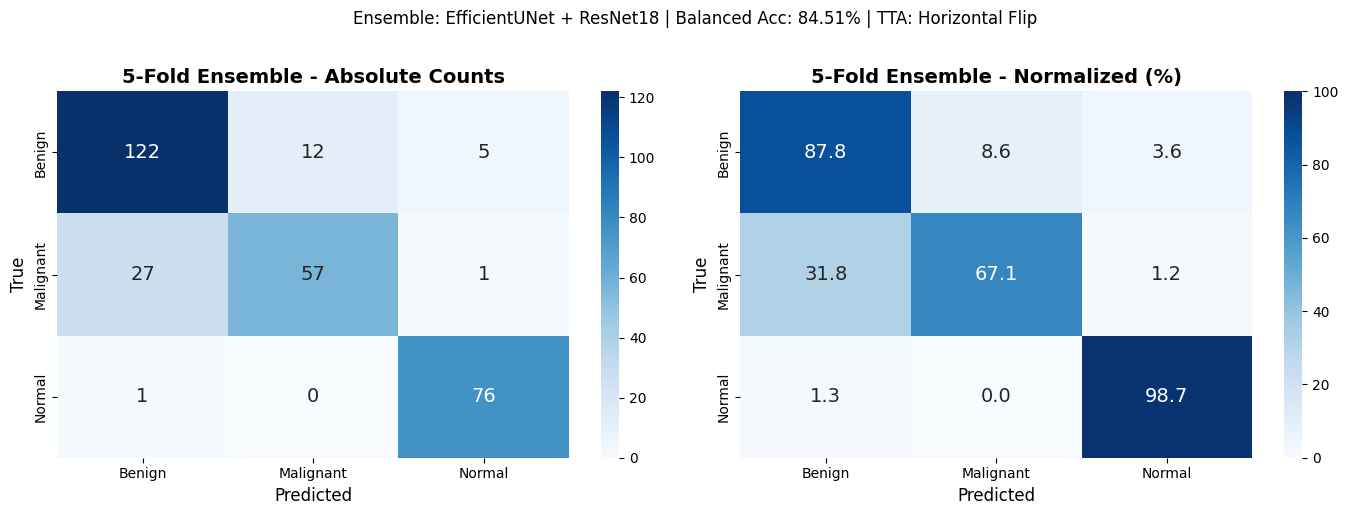


✓ Confusion matrix saved to: ensemble_confusion_matrix.png


In [11]:
# ═══════════════════════════════════════════════════════════════════════════
# CONFUSION MATRIX VISUALIZATION
# ═══════════════════════════════════════════════════════════════════════════

# Calculate confusion matrices
cm = confusion_matrix(y_true, y_pred_ensemble, labels=[0, 1, 2])
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
cm_normalized = np.nan_to_num(cm_normalized)  # Handle division by zero

# Create figure with 2 subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Absolute counts
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES,
    ax=axes[0],
    annot_kws={'size': 14}
)
axes[0].set_title('5-Fold Ensemble - Absolute Counts', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Predicted', fontsize=12)
axes[0].set_ylabel('True', fontsize=12)

# Plot 2: Normalized (percentage)
sns.heatmap(
    cm_normalized * 100,
    annot=True,
    fmt='.1f',
    cmap='Blues',
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES,
    ax=axes[1],
    annot_kws={'size': 14},
    vmin=0,
    vmax=100
)
axes[1].set_title('5-Fold Ensemble - Normalized (%)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Predicted', fontsize=12)
axes[1].set_ylabel('True', fontsize=12)

plt.suptitle(
    f'Ensemble: {MODEL_2A_ARCH} + {MODEL_2B_ARCH} | Balanced Acc: {bal_acc*100:.2f}% | TTA: Horizontal Flip',
    fontsize=12,
    y=1.02
)

plt.tight_layout()
plt.savefig('ensemble_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✓ Confusion matrix saved to: ensemble_confusion_matrix.png")

## 10. Per-Fold Analysis

In [12]:
# ═══════════════════════════════════════════════════════════════════════════
# PER-FOLD PERFORMANCE ANALYSIS
# Compare individual fold predictions vs ensemble
# ═══════════════════════════════════════════════════════════════════════════

print("="*70)
print("📈 PER-FOLD PERFORMANCE COMPARISON")
print("="*70)
print(f"\n{'Fold':<8} {'Balanced Acc':<15} {'Overall Acc':<15} {'Status'}")
print("-" * 55)

fold_results = []

for fold in range(NUM_FOLDS):
    # Get predictions from this fold's probabilities
    fold_preds = np.argmax(all_fold_probs[fold], axis=1)
    
    # Calculate metrics
    fold_bal_acc = balanced_accuracy_score(y_true, fold_preds)
    fold_overall_acc = accuracy_score(y_true, fold_preds)
    
    fold_results.append({
        'fold': fold,
        'balanced_acc': fold_bal_acc,
        'overall_acc': fold_overall_acc
    })
    
    print(f"{fold:<8} {fold_bal_acc*100:>10.2f}%     {fold_overall_acc*100:>10.2f}%     Individual")

# Print ensemble result for comparison
print("-" * 55)
print(f"{'Ensemble':<8} {bal_acc*100:>10.2f}%     {overall_acc*100:>10.2f}%     🏆 ENSEMBLE")

# Calculate improvement over average single fold
avg_single_fold_acc = np.mean([r['balanced_acc'] for r in fold_results])
improvement = (bal_acc - avg_single_fold_acc) * 100

print(f"\n📊 Ensemble Improvement: +{improvement:.2f}% over average single fold")
print(f"   Average Single Fold: {avg_single_fold_acc*100:.2f}%")
print(f"   5-Fold Ensemble:     {bal_acc*100:.2f}%")

📈 PER-FOLD PERFORMANCE COMPARISON

Fold     Balanced Acc    Overall Acc     Status
-------------------------------------------------------
0             78.25%          79.07%     Individual
1             83.92%          84.39%     Individual
2             82.55%          83.06%     Individual
3             88.21%          87.04%     Individual
4             85.89%          86.38%     Individual
-------------------------------------------------------
Ensemble      84.51%          84.72%     🏆 ENSEMBLE

📊 Ensemble Improvement: +0.75% over average single fold
   Average Single Fold: 83.76%
   5-Fold Ensemble:     84.51%


## 11. Confidence Analysis

🔍 CONFIDENCE ANALYSIS

Overall Statistics:
  Mean Confidence: 0.8846
  Std Confidence:  0.1526
  Min Confidence:  0.4000
  Max Confidence:  1.0000

Confidence by Correctness:
  Correct predictions:   0.9183 (255 samples)
  Incorrect predictions: 0.6975 (46 samples)


/tmp/ipykernel_55/410817152.py:49: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot([c for c in class_confidences if len(c) > 0],


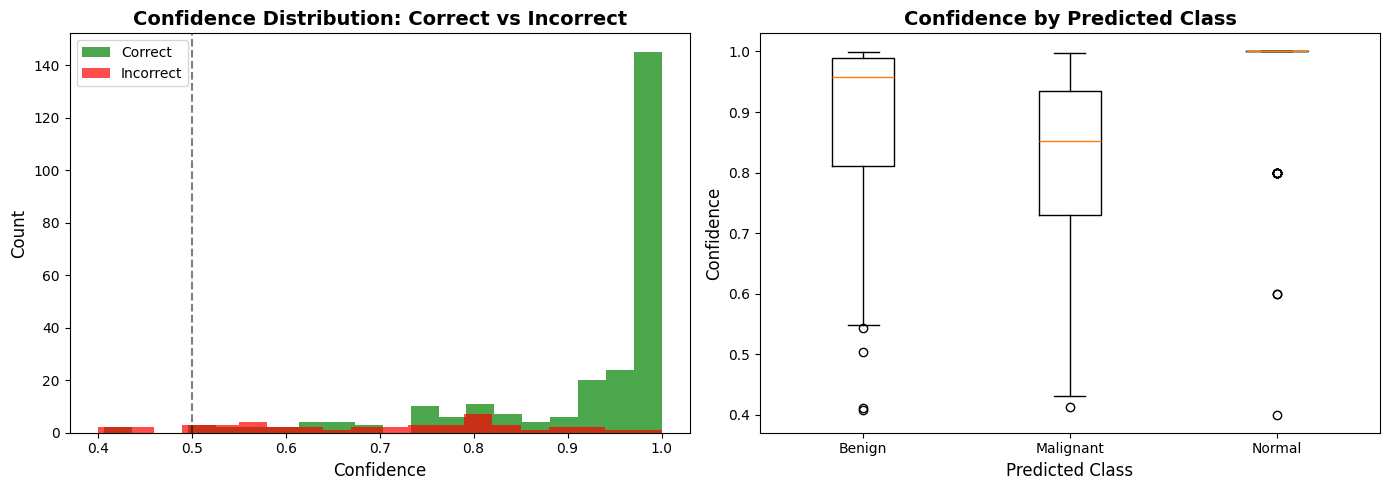


✓ Confidence analysis saved to: ensemble_confidence_analysis.png


In [13]:
# ═══════════════════════════════════════════════════════════════════════════
# CONFIDENCE ANALYSIS
# Analyze prediction confidence for correct vs incorrect predictions
# ═══════════════════════════════════════════════════════════════════════════

print("="*70)
print("🔍 CONFIDENCE ANALYSIS")
print("="*70)

# Get confidence (max probability) for each prediction
confidences = np.max(ensemble_probs, axis=1)
correct_mask = y_true == y_pred_ensemble

# Statistics
avg_conf_correct = confidences[correct_mask].mean() if correct_mask.sum() > 0 else 0
avg_conf_incorrect = confidences[~correct_mask].mean() if (~correct_mask).sum() > 0 else 0

print(f"\nOverall Statistics:")
print(f"  Mean Confidence: {confidences.mean():.4f}")
print(f"  Std Confidence:  {confidences.std():.4f}")
print(f"  Min Confidence:  {confidences.min():.4f}")
print(f"  Max Confidence:  {confidences.max():.4f}")

print(f"\nConfidence by Correctness:")
print(f"  Correct predictions:   {avg_conf_correct:.4f} ({correct_mask.sum()} samples)")
print(f"  Incorrect predictions: {avg_conf_incorrect:.4f} ({(~correct_mask).sum()} samples)")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram of confidences
axes[0].hist(confidences[correct_mask], bins=20, alpha=0.7, label='Correct', color='green')
axes[0].hist(confidences[~correct_mask], bins=20, alpha=0.7, label='Incorrect', color='red')
axes[0].set_xlabel('Confidence', fontsize=12)
axes[0].set_ylabel('Count', fontsize=12)
axes[0].set_title('Confidence Distribution: Correct vs Incorrect', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].axvline(x=0.5, color='black', linestyle='--', alpha=0.5, label='Random')

# Per-class confidence
class_confidences = []
for i, name in enumerate(CLASS_NAMES):
    class_mask = y_pred_ensemble == i
    if class_mask.sum() > 0:
        class_confidences.append(confidences[class_mask])
    else:
        class_confidences.append(np.array([]))

axes[1].boxplot([c for c in class_confidences if len(c) > 0], 
                labels=[n for i, n in enumerate(CLASS_NAMES) if len(class_confidences[i]) > 0])
axes[1].set_xlabel('Predicted Class', fontsize=12)
axes[1].set_ylabel('Confidence', fontsize=12)
axes[1].set_title('Confidence by Predicted Class', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('ensemble_confidence_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✓ Confidence analysis saved to: ensemble_confidence_analysis.png")

## 12. Save Results

In [14]:
# ═══════════════════════════════════════════════════════════════════════════
# SAVE DETAILED RESULTS
# ═══════════════════════════════════════════════════════════════════════════

print("="*70)
print("💾 SAVING RESULTS")
print("="*70)

# Create results dataframe
results_df = pd.DataFrame({
    'filename': filenames_list,
    'true_label': y_true,
    'true_class': [CLASS_NAMES[i] for i in y_true],
    'pred_label': y_pred_ensemble,
    'pred_class': [CLASS_NAMES[i] for i in y_pred_ensemble],
    'confidence': confidences,
    'prob_benign': ensemble_probs[:, 0],
    'prob_malignant': ensemble_probs[:, 1],
    'prob_normal': ensemble_probs[:, 2],
    'correct': correct_mask
})

# Add per-fold probabilities
for fold in range(NUM_FOLDS):
    results_df[f'fold_{fold}_prob_benign'] = all_fold_probs[fold, :, 0]
    results_df[f'fold_{fold}_prob_malignant'] = all_fold_probs[fold, :, 1]
    results_df[f'fold_{fold}_prob_normal'] = all_fold_probs[fold, :, 2]

# Save to CSV
output_filename = f'ensemble_predictions_{MODEL_2A_ARCH}_{MODEL_2B_ARCH}_eval_fold{EVAL_FOLD}.csv'
results_df.to_csv(output_filename, index=False)
print(f"\n✓ Predictions saved to: {output_filename}")

# Save summary
summary_lines = [
    "="*70,
    "5-FOLD ENSEMBLE INFERENCE SUMMARY",
    "="*70,
    f"Date: {pd.Timestamp.now()}",
    f"",
    f"Configuration:",
    f"  Segmentation Model (2a): {MODEL_2A_ARCH}",
    f"  Classification Model (2b): {MODEL_2B_ARCH}",
    f"  Evaluation Fold: fold_{EVAL_FOLD}_val.csv",
    f"  Mask Threshold: {MASK_THRESHOLD} pixels",
    f"  Mask Binarize Threshold: {MASK_BINARIZE_THRESHOLD}",
    f"  TTA: Horizontal Flip",
    f"  Ensemble Method: Soft Voting (Probability Averaging)",
    f"",
    f"Results:",
    f"  Total Samples: {len(y_true)}",
    f"  Balanced Accuracy: {bal_acc:.4f} ({bal_acc*100:.2f}%)",
    f"  Overall Accuracy: {overall_acc:.4f} ({overall_acc*100:.2f}%)",
    f"  Correct: {correct_mask.sum()}",
    f"  Incorrect: {(~correct_mask).sum()}",
    f"",
    f"Ensemble Improvement: +{improvement:.2f}% over average single fold",
    "="*70
]

summary_filename = f'ensemble_summary_{MODEL_2A_ARCH}_{MODEL_2B_ARCH}_eval_fold{EVAL_FOLD}.txt'
with open(summary_filename, 'w') as f:
    f.write('\n'.join(summary_lines))
print(f"✓ Summary saved to: {summary_filename}")

print("\n" + "="*70)
print("✅ ENSEMBLE INFERENCE COMPLETE")
print("="*70)

💾 SAVING RESULTS

✓ Predictions saved to: ensemble_predictions_EfficientUNet_ResNet18_eval_fold0.csv
✓ Summary saved to: ensemble_summary_EfficientUNet_ResNet18_eval_fold0.txt

✅ ENSEMBLE INFERENCE COMPLETE


## 13. Misclassification Analysis (Optional)

In [15]:
# ═══════════════════════════════════════════════════════════════════════════
# MISCLASSIFICATION ANALYSIS
# ═══════════════════════════════════════════════════════════════════════════

print("="*70)
print("❌ MISCLASSIFICATION ANALYSIS")
print("="*70)

# Get misclassified samples
misclassified = results_df[~results_df['correct']].copy()
misclassified = misclassified.sort_values('confidence', ascending=False)

print(f"\nTotal Misclassified: {len(misclassified)} / {len(results_df)} ({len(misclassified)/len(results_df)*100:.1f}%)")

# Error breakdown
print("\nError Breakdown:")
for true_class in CLASS_NAMES:
    for pred_class in CLASS_NAMES:
        if true_class != pred_class:
            count = ((results_df['true_class'] == true_class) & 
                     (results_df['pred_class'] == pred_class)).sum()
            if count > 0:
                print(f"  {true_class} → {pred_class}: {count}")

# Show top misclassified with high confidence
print("\nTop 10 High-Confidence Misclassifications:")
print(f"{'Filename':<35} {'True':<12} {'Pred':<12} {'Confidence':<12} {'Fold Variance'}")
print("-" * 85)

for idx, row in misclassified.head(10).iterrows():
    # Calculate variance across folds for the predicted class
    pred_class_idx = row['pred_label']
    fold_probs_for_pred = [row[f'fold_{f}_prob_benign'] if pred_class_idx == 0 
                          else (row[f'fold_{f}_prob_malignant'] if pred_class_idx == 1 
                                else row[f'fold_{f}_prob_normal']) 
                          for f in range(NUM_FOLDS)]
    fold_variance = np.std(fold_probs_for_pred)
    
    print(f"{row['filename']:<35} {row['true_class']:<12} {row['pred_class']:<12} "
          f"{row['confidence']:<12.4f} {fold_variance:.4f}")

❌ MISCLASSIFICATION ANALYSIS

Total Misclassified: 46 / 301 (15.3%)

Error Breakdown:
  Benign → Malignant: 12
  Benign → Normal: 5
  Malignant → Benign: 27
  Malignant → Normal: 1
  Normal → Benign: 1

Top 10 High-Confidence Misclassifications:
Filename                            True         Pred         Confidence   Fold Variance
-------------------------------------------------------------------------------------
460.png                             Benign       Normal       1.0000       0.0000
901.png                             Benign       Malignant    0.9611       0.0291
876.png                             Malignant    Benign       0.9150       0.0594
896.png                             Malignant    Benign       0.9140       0.0658
792.png                             Malignant    Benign       0.9084       0.0648
955.png                             Malignant    Benign       0.9041       0.0813
911.png                             Benign       Malignant    0.8528       0.1324
930.p